# ============================================================
# PHASE 06 — APPLIED REPRESENTATION ANALYSIS
# STEP 05 — TOKEN INTERACTION ANALYSIS
# ============================================================

# Repository Philosophy:
#
# Tensor intuition first.
# Representation systems second.
# Architecture complexity later.
#
# ------------------------------------------------------------
# CENTRAL QUESTION OF THIS STEP
# ------------------------------------------------------------
#
# How do tokens contextually influence each other
# inside transformer systems?
#
# Earlier we visualized:
#
#     attention distributions
#
# Now we investigate something deeper:
#
#     token interaction dynamics.
#
# This step studies:
#
#     • token influence patterns
#     • contextual interaction
#     • semantic routing
#     • interaction topology
#     • contextual representation evolution
#
# using REAL transformer systems.
#
# ============================================================



============================================================
1. CONCEPTUAL INTRODUCTION
============================================================

CONCEPTUAL FOUNDATION
---------------------

Transformers do NOT process words independently.

Instead:

    every token continuously interacts
    with other tokens.

------------------------------------------------------------
IMPORTANT TRANSITION
------------------------------------------------------------

Earlier steps studied:

    static semantic geometry.

Then:

    attention routing.

Now we investigate:

    how interaction changes meaning itself.

------------------------------------------------------------
EXAMPLE
------------------------------------------------------------

Consider:

    "The scientist analyzed the data."

The token:

    analyzed

may strongly interact with:

    scientist
    data

These interactions influence:

    contextual representation formation.

------------------------------------------------------------
CORE IDEA
------------------------------------------------------------

Meaning may emerge through:

    interaction pathways

between representations.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Could cognition itself emerge through:

    contextual interaction networks?




============================================================
2. REPRESENTATION HYPOTHESIS
============================================================

REPRESENTATION HYPOTHESIS
-------------------------

Hypothesis:

    different tokens will form
    structured contextual interaction patterns.

Expected observations:

    • nouns influence verbs
    • adjectives influence nearby nouns
    • important semantic tokens become hubs
    • context changes interaction structure

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Tokens do NOT possess isolated meaning.

Instead:

    meaning evolves through interaction.

------------------------------------------------------------
THINK DEEPLY
------------------------------------------------------------

Is language fundamentally:

    a dynamic interaction system?




============================================================
3. LOAD REAL TRANSFORMER SYSTEM
============================================================

We now load a REAL transformer model.

------------------------------------------------------------
MODEL
------------------------------------------------------------

We use:

    BERT

because it provides:

    • attention matrices
    • contextual hidden states
    • multi-layer interaction dynamics

------------------------------------------------------------
GLOSSARY OF FUNCTIONS
------------------------------------------------------------

BertTokenizer.from_pretrained(...)
    Loads tokenizer.

BertModel.from_pretrained(...)
    Loads transformer model.

output_attentions=True
    Returns attention matrices.

output_hidden_states=True
    Returns hidden representations.

softmax(...)
    Converts scores into probability distributions.

torch.mean(...)
    Computes average interaction strength.

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Transformers construct:

    contextual interaction graphs

between tokens.




In [2]:

import torch

from transformers import (
    BertTokenizer,
    BertModel
)

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

# Load transformer model
model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True,
    output_hidden_states=True
)

print("Transformer system loaded successfully.")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer system loaded successfully.


============================================================
4. TOKENIZATION AND INPUT PROCESSING
============================================================

Transformers first convert text into:

    token sequences.

------------------------------------------------------------
NOTE ON SPECIAL TOKENS
------------------------------------------------------------

The tokenizer automatically inserts:

    [CLS]
    [SEP]

[CLS]

    Global contextual aggregation token.

[SEP]

    Sequence boundary token.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

These tokens actively participate
in contextual interaction dynamics.

------------------------------------------------------------
QUESTION
------------------------------------------------------------

Which tokens will dominate
contextual information flow?




In [3]:

sentence = (
    "The scientist analyzed the transformer attention system carefully."
)

# Tokenize sentence
inputs = tokenizer(
    sentence,
    return_tensors="pt"
)

# Convert token IDs back into readable tokens
tokens = tokenizer.convert_ids_to_tokens(
    inputs["input_ids"][0]
)

print("\nTOKENS\n")

print(tokens)




TOKENS

['[CLS]', 'the', 'scientist', 'analyzed', 'the', 'transform', '##er', 'attention', 'system', 'carefully', '.', '[SEP]']


============================================================
5. ATTENTION INTERACTION MATHEMATICS
============================================================

CORE IDEA
---------

Attention defines:

    token-to-token interaction strength.

============================================================
QUERY-KEY-VALUE SYSTEM
============================================================

Each token generates:

    • Query vector (Q)
    • Key vector (K)
    • Value vector (V)

------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------

Query:

    "What information am I seeking?"

Key:

    "What information do I contain?"

Value:

    "What information should I contribute?"

============================================================
ATTENTION MATRIX
============================================================

Raw interaction scores:





------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------

Each matrix entry:

    S(i,j)

measures:

    interaction strength between token i and token j.

============================================================
SCALED ATTENTION MATRIX
============================================================





Scaling stabilizes:

    high-dimensional attention computation.

============================================================
FINAL ATTENTION DISTRIBUTION
============================================================





where:

    A(i,j)

represents:

    how strongly token i attends to token j.

============================================================
CONTEXTUAL REPRESENTATION UPDATE
============================================================




This creates:

    context-aware token representations.

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Representations evolve through:

    weighted interaction with other tokens.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Could contextual meaning itself emerge through:

    interaction-weighted representation evolution?




============================================================
6. EXTRACT TOKEN INTERACTION STRUCTURE
============================================================

We now pass text through the transformer.

The model returns:

    • hidden states
    • attention matrices

------------------------------------------------------------
ATTENTION TENSOR STRUCTURE
------------------------------------------------------------

Attention dimensions:

    [batch, heads, tokens, tokens]

Example:

    [1, 12, 10, 10]

meaning:

    • 1 sentence
    • 12 attention heads
    • 10 query tokens
    • 10 attended tokens

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Each head learns:

    different interaction patterns.




In [4]:

# Forward pass

with torch.no_grad():

    outputs = model(**inputs)

# Extract attention tensors
attentions = outputs.attentions

# Extract hidden states
hidden_states = outputs.hidden_states

print("Number of transformer layers:")
print(len(attentions))

print("\nAttention tensor shape:")
print(attentions[0].shape)



Number of transformer layers:
12

Attention tensor shape:
torch.Size([1, 12, 12, 12])


============================================================
7. TOKEN INTERACTION ANALYSIS
============================================================

We now analyze:

    how tokens influence each other.

------------------------------------------------------------
CORE IDEA
------------------------------------------------------------

Strong attention:

    stronger contextual interaction.

------------------------------------------------------------
IMPORTANT QUESTION
------------------------------------------------------------

Which tokens become:

    contextual influence hubs?




In [5]:

# Select:
# Layer 0
# Head 0

attention_matrix = attentions[0][0][0]

print("Attention matrix shape:")
print(attention_matrix.shape)



Attention matrix shape:
torch.Size([12, 12])


In [6]:

print("\nTOKEN INTERACTION STRENGTHS\n")

for i, source_token in enumerate(tokens):

    print("=" * 60)
    print(f"QUERY TOKEN: {source_token}")
    print("=" * 60)

    interaction_scores = attention_matrix[i]

    for j, target_token in enumerate(tokens):

        score = interaction_scores[j].item()

        print(
            f"{source_token:15s} -> "
            f"{target_token:15s} "
            f"Attention: {score:.4f}"
        )

    print()




TOKEN INTERACTION STRENGTHS

QUERY TOKEN: [CLS]
[CLS]           -> [CLS]           Attention: 0.0489
[CLS]           -> the             Attention: 0.1111
[CLS]           -> scientist       Attention: 0.0319
[CLS]           -> analyzed        Attention: 0.0263
[CLS]           -> the             Attention: 0.1149
[CLS]           -> transform       Attention: 0.0457
[CLS]           -> ##er            Attention: 0.0432
[CLS]           -> attention       Attention: 0.0612
[CLS]           -> system          Attention: 0.0764
[CLS]           -> carefully       Attention: 0.0760
[CLS]           -> .               Attention: 0.1021
[CLS]           -> [SEP]           Attention: 0.2623

QUERY TOKEN: the
the             -> [CLS]           Attention: 0.0878
the             -> the             Attention: 0.0939
the             -> scientist       Attention: 0.0573
the             -> analyzed        Attention: 0.0501
the             -> the             Attention: 0.1184
the             -> transform    

============================================================
8. CONTEXTUAL INTERACTION HEATMAP
============================================================

Human beings cannot directly interpret:

    high-dimensional interaction matrices.

So we visualize:

    interaction heatmaps.

------------------------------------------------------------
HEATMAP INTERPRETATION
------------------------------------------------------------

Rows:

    querying tokens

Columns:

    attended tokens

Bright regions:

    stronger contextual influence.

------------------------------------------------------------
IMPORTANT QUESTION
------------------------------------------------------------

Which semantic regions dominate:

    contextual information routing?




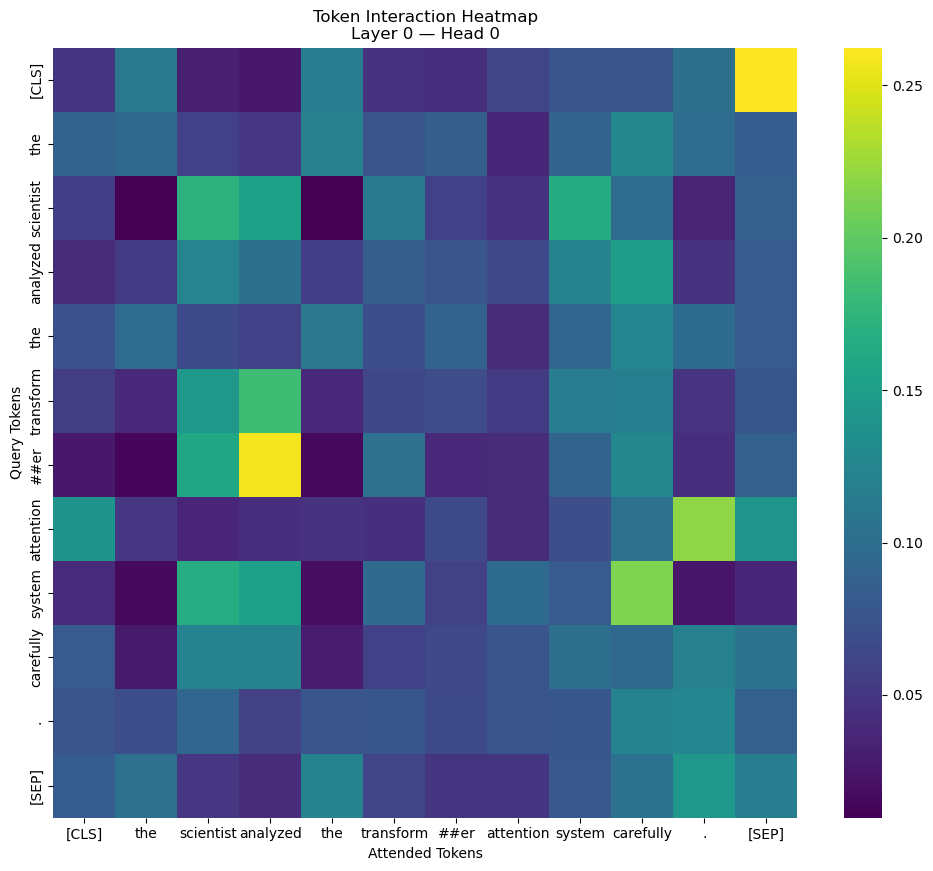

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

# Convert attention matrix to NumPy
interaction_map = attention_matrix.cpu().numpy()

plt.figure(figsize=(12, 10))

sns.heatmap(
    interaction_map,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="viridis",
    annot=False
)

plt.title(
    "Token Interaction Heatmap\n"
    "Layer 0 — Head 0"
)

plt.xlabel("Attended Tokens")
plt.ylabel("Query Tokens")

plt.show()



============================================================
9. TOKEN INFLUENCE ANALYSIS
============================================================

We now measure:

    global token influence.

------------------------------------------------------------
CORE IDEA
------------------------------------------------------------

Some tokens may become:

    interaction hubs.

These tokens attract:

    strong contextual attention.

------------------------------------------------------------
IMPORTANT INSIGHT
------------------------------------------------------------

Transformers dynamically construct:

    contextual importance structure.




In [8]:

# Compute average incoming attention

incoming_attention = torch.mean(
    attention_matrix,
    dim=0
)

print("\nGLOBAL TOKEN INFLUENCE\n")

for token, score in zip(tokens, incoming_attention):

    print(
        f"{token:15s} "
        f"Global Influence: {score.item():.4f}"
    )




GLOBAL TOKEN INFLUENCE

[CLS]           Global Influence: 0.0671
the             Global Influence: 0.0567
scientist       Global Influence: 0.1017
analyzed        Global Influence: 0.1042
the             Global Influence: 0.0630
transform       Global Influence: 0.0741
##er            Global Influence: 0.0634
attention       Global Influence: 0.0566
system          Global Influence: 0.0963
carefully       Global Influence: 0.1213
.               Global Influence: 0.0916
[SEP]           Global Influence: 0.1038


============================================================
10. CONTEXTUAL REPRESENTATION EVOLUTION
============================================================

Transformers continuously update:

    token representations.

------------------------------------------------------------
IMPORTANT IDEA
------------------------------------------------------------

Initial embeddings:

    static semantic vectors

Final hidden states:

    contextualized semantic states

------------------------------------------------------------
REPRESENTATION EVOLUTION
------------------------------------------------------------

Earlier layers:

    local interactions

Later layers:

    abstract contextual structure

------------------------------------------------------------
VERY IMPORTANT INSIGHT
------------------------------------------------------------

Meaning evolves dynamically
across transformer depth.




In [9]:

print("\nHIDDEN STATE STRUCTURE\n")

print("Number of hidden-state layers:")
print(len(hidden_states))

print("\nHidden-state tensor shape:")
print(hidden_states[0].shape)




HIDDEN STATE STRUCTURE

Number of hidden-state layers:
13

Hidden-state tensor shape:
torch.Size([1, 12, 768])


============================================================
11. INTERPRETATION
============================================================

OBSERVATION ANALYSIS
--------------------

Examine the interaction heatmap carefully.

Possible observations:

    • important nouns attract attention
    • nearby words interact strongly
    • semantic tokens become hubs
    • structural tokens organize flow

------------------------------------------------------------
IMPORTANT REALIZATION
------------------------------------------------------------

Transformers operate through:

    dynamic contextual interaction.

Meaning is NOT statically stored.

Instead:

    representations continuously influence each other.

------------------------------------------------------------
TOKEN INTERACTION AS GRAPH DYNAMICS
------------------------------------------------------------

The attention matrix defines:

    a weighted interaction graph.

Tokens become:

    dynamically interacting nodes.

------------------------------------------------------------
VERY IMPORTANT INSIGHT
------------------------------------------------------------

Contextual meaning may emerge through:

    interaction topology.

------------------------------------------------------------
DEEP QUESTION
------------------------------------------------------------

Could cognition itself emerge from:

    evolving interaction graphs

inside representation systems?




============================================================
12. FAILURE CASES
============================================================

REAL SYSTEMS ARE IMPERFECT
--------------------------

Attention analysis possesses limitations.

------------------------------------------------------------
LIMITATION 1 — ATTENTION ≠ CAUSAL REASONING
------------------------------------------------------------

High attention does NOT guarantee:

    causal importance.

Attention reflects:

    interaction weighting

not complete reasoning structure.

------------------------------------------------------------
LIMITATION 2 — MULTI-HEAD COMPLEXITY
------------------------------------------------------------

Different heads learn:

    different interaction patterns.

One head shows only:

    partial system behavior.

------------------------------------------------------------
LIMITATION 3 — CONTEXT DEPENDENCE
------------------------------------------------------------

Interaction topology changes:

    sentence-by-sentence.

------------------------------------------------------------
LIMITATION 4 — VISUALIZATION SIMPLIFICATION
------------------------------------------------------------

Heatmaps compress:

    extremely high-dimensional dynamics.

------------------------------------------------------------
THINK CRITICALLY
------------------------------------------------------------

Is attention sufficient to explain:

    transformer cognition?




============================================================
13. SCIENTIFIC INSIGHT
============================================================

MOST IMPORTANT INSIGHT
----------------------

Transformers fundamentally operate through:

    dynamic interaction systems.

------------------------------------------------------------
TOKEN INTERACTIONS ENABLE
------------------------------------------------------------

    • contextual reasoning
    • semantic disambiguation
    • adaptive representation routing
    • long-range dependency modeling
    • contextual reinterpretation

------------------------------------------------------------
FOUNDATIONAL REALIZATION
------------------------------------------------------------

Meaning emerges through:

    evolving interaction topology.

------------------------------------------------------------
IMPORTANT TRANSITION
------------------------------------------------------------

We are no longer studying:

    isolated embeddings

but:

    adaptive contextual computation systems.

------------------------------------------------------------
LOOK AHEAD
------------------------------------------------------------

Next steps investigate:

    • head specialization
    • contextual representation shift
    • layerwise representation evolution
    • latent semantic dynamics

We are progressively uncovering:

    AI as dynamic representation cognition.




============================================================
14. EXPLORATION EXERCISES
============================================================

EXPLORATION 1
-------------

Compare:

    simple vs complex sentences.

Does interaction topology become:

    more distributed?

------------------------------------------------------------
EXPLORATION 2
-------------

Try ambiguous sentences:

    "The bank approved the loan."
    "The boat reached the bank."

How does interaction structure change?

------------------------------------------------------------
EXPLORATION 3
-------------

Compare:

    different transformer layers.

Do deeper layers learn:

    more abstract interaction patterns?

------------------------------------------------------------
EXPLORATION 4
-------------

Compare:

    different attention heads.

Do some heads specialize in:

    syntax?
    semantics?
    positional structure?

------------------------------------------------------------
EXPLORATION 5
-------------

Replace BERT with:

    • RoBERTa
    • DistilBERT
    • GPT-2

How does token interaction topology change?

------------------------------------------------------------
FINAL QUESTION
------------------------------------------------------------

If intelligence emerges through:

    dynamic interaction systems,

then could cognition fundamentally be:

    evolving representation topology?

============================================================